<a href="https://colab.research.google.com/github/HamzaAshfaq95/Patent-Data-Analysis-Trend-Discovery/blob/main/Patent_Data_Analysis_%26_Trend_Discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For a Patent Data Analysis & Trend Discovery project, the goal is to answer business, technology, and innovation questions using exploratory data analysis (EDA).

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Patent Data Analysis/patent_dataset.csv")

In [12]:
df.isnull().sum()

,0
patent_id,0
title,0
filing_year,0
grant_year,0
country,0
assignee,0
technology_field,0
citations,0
inventor_count,0
patent_status,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patent_id           12000 non-null  object
 1   title               12000 non-null  object
 2   filing_year         12000 non-null  int64 
 3   grant_year          12000 non-null  int64 
 4   country             12000 non-null  object
 5   assignee            12000 non-null  object
 6   technology_field    12000 non-null  object
 7   citations           12000 non-null  int64 
 8   inventor_count      12000 non-null  int64 
 9   patent_status       12000 non-null  object
 10  patent_family_size  12000 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 1.0+ MB


***Data Overview Questions***

In [16]:
# How many patents are in the dataset?
df.title.count()

np.int64(12000)

In [18]:
# What is the time range of the patents (earliest and latest filing year)?
df.filing_year.max()

2025

In [19]:
df.filing_year.min()

2010

In [25]:
# How many countries are represented?
df.country.nunique()

10

In [26]:
# How many unique companies (assignees) filed patents?
df.assignee.nunique()

12

In [27]:
# How many technology fields are present?
df.technology_field.nunique()

10

***Country-Level Analysis***

In [34]:
# Which countries file the most patents?
top_country = df['country'].value_counts().idxmax()
top_country

'India'

In [48]:
# How has patent filing changed by country over time?
df.groupby(["filing_year", "country"]).size().unstack()

country,Canada,China,France,Germany,India,Japan,South Korea,Switzerland,UK,USA
filing_year,,,,,,,,,,
2010,89,73,81,79,80,66,86,68,79,65
2011,80,79,67,81,90,65,73,80,72,72
2012,88,64,79,73,67,72,69,60,74,88
2013,66,76,76,70,91,73,76,70,63,72
2014,84,74,70,71,78,69,80,60,77,90
2015,81,65,78,74,77,71,60,83,70,69
2016,72,80,95,70,77,63,74,78,67,70
2017,72,70,70,66,82,53,61,78,81,98
2018,66,73,77,71,92,87,76,81,71,72


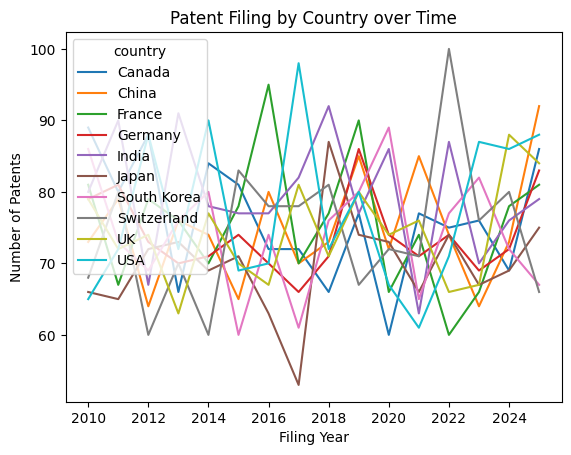

In [47]:
df.groupby(["filing_year", "country"]).size().unstack().plot()
plt.title("Patent Filing by Country over Time")
plt.xlabel("Filing Year")
plt.ylabel("Number of Patents")
plt.show()

In [51]:
# Which countries dominate specific technologies?
df.groupby(["country", "technology_field"]).size().unstack()

technology_field,Artificial Intelligence,Biotechnology,Electric Vehicles,Nanotechnology,Pharmaceuticals,Quantum Computing,Renewable Energy,Robotics,Semiconductors,Telecommunications
country,,,,,,,,,,
Canada,132,130,117,109,112,124,111,116,136,131
China,107,127,119,96,116,131,127,145,118,113
France,130,104,130,123,107,116,121,130,119,128
Germany,117,109,110,125,110,123,119,127,125,119
India,131,130,122,127,110,128,137,133,124,130
Japan,117,116,120,95,110,110,129,105,106,109
South Korea,127,126,121,104,125,122,111,124,105,122
Switzerland,119,113,125,109,134,135,128,101,122,104
UK,124,138,120,128,119,121,113,115,94,117


In [56]:
df.groupby(["country", "technology_field"]).size().unstack().idxmax(axis=1)

,0
country,
Canada,Semiconductors
China,Robotics
France,Artificial Intelligence
Germany,Robotics
India,Renewable Energy
Japan,Renewable Energy
South Korea,Artificial Intelligence
Switzerland,Quantum Computing
UK,Biotechnology


In [76]:
# Which countries have the highest average citations?
# avg_citations = df.groupby("country").agg({"citations": "mean"})
avg_citations = df.groupby("country")["citations"].mean()
print(avg_citations.idxmax(), round(avg_citations.max(), 2))

India 126.61


In [83]:
# Which countries show the fastest growth in patent filings?
patent_counts = df.groupby(["filing_year", "country"]).size().unstack(fill_value=0)

In [95]:
# First way to check growth using CAGR-style growth
overall_growth = (patent_counts.iloc[-1] - patent_counts.iloc[0]) / patent_counts.iloc[0] * 100
overall_growth.sort_values(ascending=False)

,0
country,
USA,35.384615
China,26.027397
Japan,13.636364
UK,6.329114
Germany,5.063291
France,0.000000
India,-1.250000
Switzerland,-2.941176
Canada,-3.370787


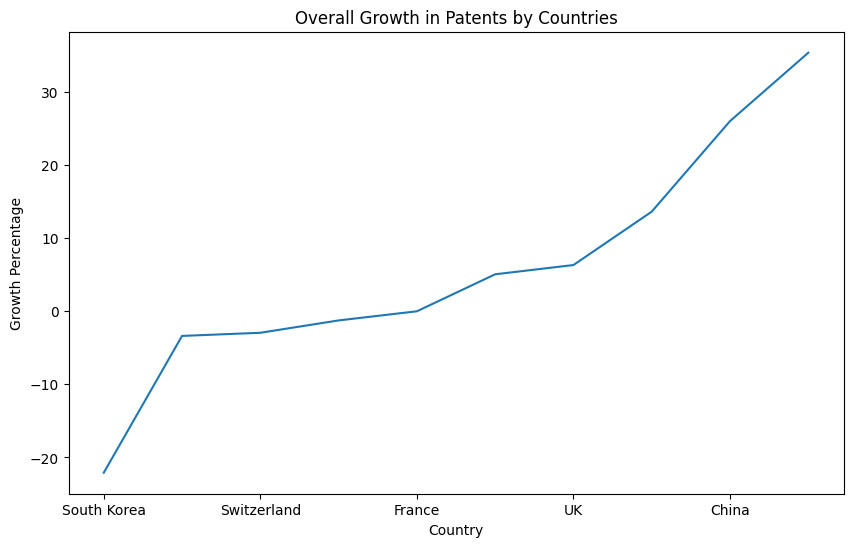

In [100]:
overall_growth.sort_values().plot(figsize=(10,6))
plt.title("Overall Growth in Patents by Countries")
plt.xlabel("Country")
plt.ylabel("Growth Percentage")
plt.show()

In [107]:
# Second way to check growth using pct_change but we can't check overall growth using this
ovrall_grwth = patent_counts.pct_change().fillna(0)
ovrall_grwth

country,Canada,China,France,Germany,India,Japan,South Korea,Switzerland,UK,USA
filing_year,,,,,,,,,,
2010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011,-0.101124,0.082192,-0.172840,0.025316,0.125000,-0.015152,-0.151163,0.176471,-0.088608,0.107692
2012,0.100000,-0.189873,0.179104,-0.098765,-0.255556,0.107692,-0.054795,-0.250000,0.027778,0.222222
2013,-0.250000,0.187500,-0.037975,-0.041096,0.358209,0.013889,0.101449,0.166667,-0.148649,-0.181818
2014,0.272727,-0.026316,-0.078947,0.014286,-0.142857,-0.054795,0.052632,-0.142857,0.222222,0.250000
2015,-0.035714,-0.121622,0.114286,0.042254,-0.012821,0.028986,-0.250000,0.383333,-0.090909,-0.233333
2016,-0.111111,0.230769,0.217949,-0.054054,0.000000,-0.112676,0.233333,-0.060241,-0.042857,0.014493
2017,0.000000,-0.125000,-0.263158,-0.057143,0.064935,-0.158730,-0.175676,0.000000,0.208955,0.400000
2018,-0.083333,0.042857,0.100000,0.075758,0.121951,0.641509,0.245902,0.038462,-0.123457,-0.265306


***Technology Trend Questions***

In [113]:
# Which technology fields have the most patents?
top_tech = df.technology_field.value_counts()
top_tech

,count
technology_field,
Artificial Intelligence,1230
Quantum Computing,1224
Biotechnology,1223
Robotics,1219
Renewable Energy,1206
Electric Vehicles,1199
Telecommunications,1190
Pharmaceuticals,1180
Semiconductors,1178


In [110]:
# Normalize to See Percentage
df.technology_field.value_counts(normalize=True) * 100

,proportion
technology_field,
Artificial Intelligence,10.250000
Quantum Computing,10.200000
Biotechnology,10.191667
Robotics,10.158333
Renewable Energy,10.050000
Electric Vehicles,9.991667
Telecommunications,9.916667
Pharmaceuticals,9.833333
Semiconductors,9.816667


Text(0, 0.5, 'Number of Patents')

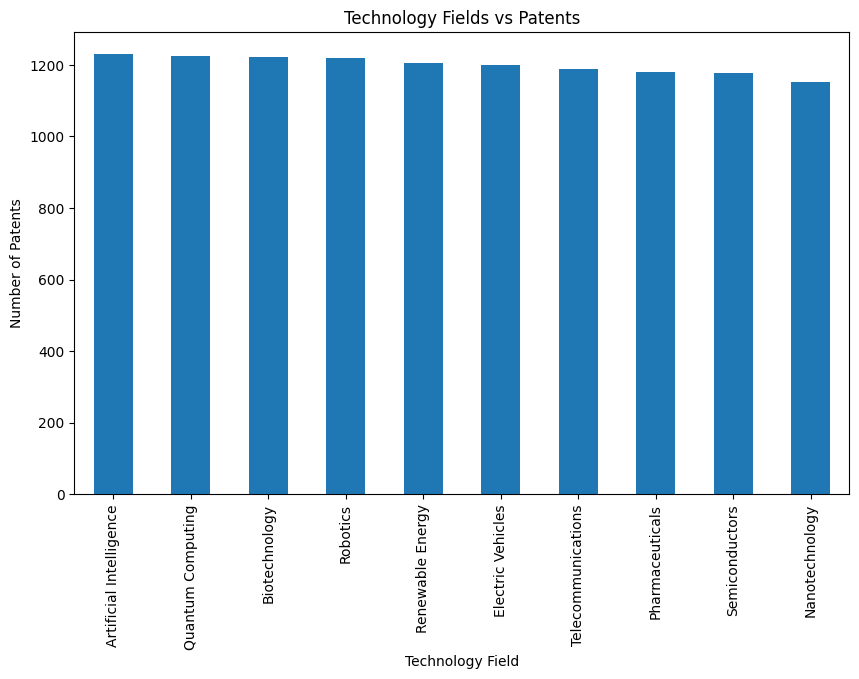

In [114]:
top_tech.plot(kind='bar', figsize=(10,6))
plt.title("Technology Fields vs Patents")
plt.xlabel("Technology Field")
plt.ylabel("Number of Patents")

In [116]:
# Which technologies are growing the fastest?
tech_change = df.groupby(["filing_year", "technology_field"]).size().unstack(fill_value=0)

In [119]:
tech_growth = (tech_change.iloc[-1] - tech_change.iloc[0]) / tech_change.iloc[0] * 100
tech_growth.sort_values(ascending=False)

,0
technology_field,
Robotics,50.704225
Artificial Intelligence,31.250000
Pharmaceuticals,12.328767
Electric Vehicles,11.688312
Telecommunications,6.944444
Nanotechnology,-4.000000
Quantum Computing,-4.761905
Renewable Energy,-8.235294
Biotechnology,-15.384615


In [121]:
# Which technologies receive the most citations?
df.groupby("technology_field")["citations"].sum().sort_values(ascending=False)

,citations
technology_field,
Quantum Computing,157474
Renewable Energy,151947
Artificial Intelligence,151393
Biotechnology,150879
Telecommunications,149672
Robotics,148222
Electric Vehicles,147848
Pharmaceuticals,145643
Nanotechnology,141295


In [124]:
# Which technologies appeared recently in the dataset?
recent_tech = df.groupby('technology_field')['filing_year'].min()
recent_tech

,filing_year
technology_field,
Artificial Intelligence,2010
Biotechnology,2010
Electric Vehicles,2010
Nanotechnology,2010
Pharmaceuticals,2010
Quantum Computing,2010
Renewable Energy,2010
Robotics,2010
Semiconductors,2010


In [125]:
recent_tech[recent_tech == recent_tech.max()]

,filing_year
technology_field,
Artificial Intelligence,2010
Biotechnology,2010
Electric Vehicles,2010
Nanotechnology,2010
Pharmaceuticals,2010
Quantum Computing,2010
Renewable Energy,2010
Robotics,2010
Semiconductors,2010


In [126]:
# Which technologies are declining over time?
tech_change = df.groupby(["filing_year", "technology_field"]).size().unstack(fill_value=0)
tech_growth = (tech_change.iloc[-1] - tech_change.iloc[0]) / tech_change.iloc[0] * 100
tech_growth.sort_values()

,0
technology_field,
Semiconductors,-20.689655
Biotechnology,-15.384615
Renewable Energy,-8.235294
Quantum Computing,-4.761905
Nanotechnology,-4.000000
Telecommunications,6.944444
Electric Vehicles,11.688312
Pharmaceuticals,12.328767
Artificial Intelligence,31.250000


***Company / Assignee Analysis***

In [129]:
# Which companies filed the most patents?
assignee_counts = df.assignee.value_counts()
print(assignee_counts.idxmax(), assignee_counts.max())

MedGenome Labs 1050


In [134]:
# Which companies have high-impact patents (highest citations)?
high_impact = df.groupby("assignee")["citations"].sum().sort_values(ascending=False)
print(high_impact.idxmax(), high_impact.max())

AI Dynamics 131959


In [139]:
# Which companies focus on specific technologies?
df.groupby("assignee")["technology_field"].value_counts()

assignee       technology_field       
AI Dynamics    Pharmaceuticals            114
               Quantum Computing          114
               Robotics                   114
               Renewable Energy           113
               Nanotechnology             104
                                         ... 
TechNova Corp  Robotics                    97
               Pharmaceuticals             91
               Artificial Intelligence     90
               Nanotechnology              88
               Semiconductors              88
Name: count, Length: 120, dtype: int64

In [140]:
# See Top Technology Per Company
df.groupby("assignee")["technology_field"].value_counts().groupby(level=0).head(1)

,,count
assignee,technology_field,
AI Dynamics,Pharmaceuticals,114
BioHealth Inc,Electric Vehicles,122
FutureDrive Motors,Renewable Energy,112
Global Energy Systems,Semiconductors,121
GreenFuture Labs,Robotics,112
InnovateX,Renewable Energy,115
MedGenome Labs,Quantum Computing,117
NanoWorks,Quantum Computing,120
NextGen Robotics,Artificial Intelligence,107


In [144]:
# How many patents does each company file per year?
df.groupby(["filing_year", "assignee"]).size().unstack()

assignee,AI Dynamics,BioHealth Inc,FutureDrive Motors,Global Energy Systems,GreenFuture Labs,InnovateX,MedGenome Labs,NanoWorks,NextGen Robotics,Quantum Circuits Ltd,SmartComm Technologies,TechNova Corp
filing_year,,,,,,,,,,,,
2010,81,56,67,63,65,60,62,61,68,62,66,55
2011,58,70,80,46,48,74,54,75,62,76,60,56
2012,67,68,65,66,61,59,63,74,52,55,49,55
2013,68,61,49,58,73,61,65,65,59,52,59,63
2014,67,45,54,61,55,84,67,61,60,75,67,57
2015,78,55,55,66,60,60,69,67,55,57,52,54
2016,59,66,68,65,57,68,53,62,72,60,55,61
2017,63,69,54,63,67,51,63,60,55,64,64,58
2018,58,75,79,65,73,62,67,44,62,61,53,67


In [148]:
# Which companies have growing innovation activity?
comp_growth = df.groupby(["filing_year", "assignee"]).size().unstack(fill_value=0)
comp_growth_change = (comp_growth.iloc[-1] - comp_growth.iloc[0]) / comp_growth.iloc[0] * 100
comp_growth_change.sort_values(ascending=False)

,0
assignee,
TechNova Corp,30.909091
GreenFuture Labs,18.461538
Global Energy Systems,17.460317
SmartComm Technologies,16.666667
MedGenome Labs,16.129032
BioHealth Inc,8.928571
InnovateX,3.333333
AI Dynamics,-2.469136
NextGen Robotics,-5.882353


***Time-Based Trend Questions***

In [154]:
# How has total patent filing changed over time?
df.filing_year.value_counts().sort_index()

,count
filing_year,
2010,766
2011,759
2012,734
2013,733
2014,753
2015,728
2016,746
2017,731
2018,766


Text(0, 0.5, 'Number of Patents')

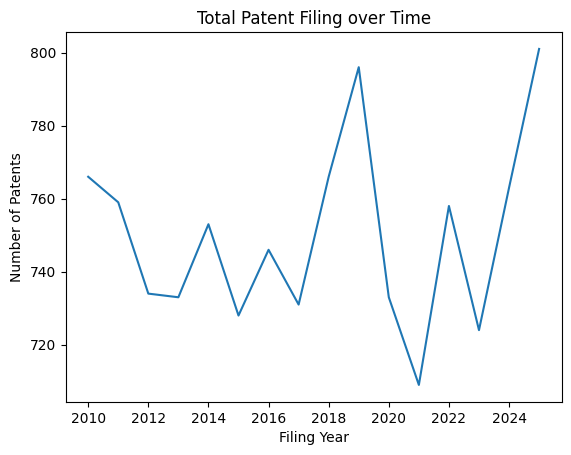

In [159]:
# Are patent filings increasing or decreasing overall?
df.filing_year.value_counts().sort_index().plot()
plt.title("Total Patent Filing over Time")
plt.xlabel("Filing Year")
plt.ylabel("Number of Patents")

In [158]:
# Which years had the highest patent activity?
count_by_year = df.filing_year.value_counts().sort_index(ascending=False)
print(count_by_year.idxmax(), count_by_year.max())

2025 801


In [166]:
# Which technologies are trending upward each year?
tech_by_year = df.groupby(["filing_year", "technology_field"]).size().unstack(fill_value=0)
tech_by_year_change = (tech_by_year.iloc[-1] - tech_by_year.iloc[0]) / tech_by_year.iloc[0] * 100
tech_by_year_change.sort_values(ascending=False)

,0
technology_field,
Robotics,50.704225
Artificial Intelligence,31.250000
Pharmaceuticals,12.328767
Electric Vehicles,11.688312
Telecommunications,6.944444
Nanotechnology,-4.000000
Quantum Computing,-4.761905
Renewable Energy,-8.235294
Biotechnology,-15.384615


***Patent Impact Analysis***

In [173]:
# Which patents have the highest citations?
max_citations = df[df['citations'] == df['citations'].max()]
max_citations[["title", "assignee", "technology_field", "citations"]]

,title,assignee,technology_field,citations
867,Innovative Pharmaceuticals System 868,GreenFuture Labs,Robotics,250
1003,Innovative Pharmaceuticals System 1004,AI Dynamics,Pharmaceuticals,250
1063,Innovative Pharmaceuticals System 1064,BioHealth Inc,Robotics,250
1471,Innovative Semiconductors System 1472,BioHealth Inc,Artificial Intelligence,250
1695,Innovative Quantum Computing System 1696,FutureDrive Motors,Renewable Energy,250
2359,Innovative Robotics System 2360,FutureDrive Motors,Nanotechnology,250
2406,Innovative Pharmaceuticals System 2407,InnovateX,Biotechnology,250
2993,Innovative Pharmaceuticals System 2994,FutureDrive Motors,Electric Vehicles,250
3060,Innovative Semiconductors System 3061,GreenFuture Labs,Artificial Intelligence,250
3147,Innovative Robotics System 3148,InnovateX,Quantum Computing,250


In [175]:
# Which technologies have the highest average citations?
df.groupby("technology_field")["citations"].mean().sort_values(ascending=False)

,citations
technology_field,
Quantum Computing,128.655229
Renewable Energy,125.992537
Telecommunications,125.774790
Pharmaceuticals,123.426271
Biotechnology,123.367948
Electric Vehicles,123.309425
Artificial Intelligence,123.083740
Nanotechnology,122.758471
Robotics,121.593109


In [178]:
# Which companies produce highly cited patents?
df.groupby("assignee")["citations"].max().sort_values(ascending=False)

,citations
assignee,
AI Dynamics,250
BioHealth Inc,250
FutureDrive Motors,250
Global Energy Systems,250
GreenFuture Labs,250
InnovateX,250
MedGenome Labs,250
NanoWorks,250
NextGen Robotics,250


In [182]:
# Do patents with more inventors receive more citations?
df.groupby('inventor_count')['citations'].mean().sort_index()

,citations
inventor_count,
1,122.300500
2,125.523127
3,124.404824
4,128.284810
5,122.095612
6,120.564667
7,123.358142
8,123.283632


***Innovation Collaboration Questions***

In [184]:
# What is the average number of inventors per patent?
df.inventor_count.mean()

np.float64(4.539333333333333)

In [186]:
# Which technology requires larger research teams?
df.groupby("technology_field")["inventor_count"].mean().sort_values(ascending=False)

,inventor_count
technology_field,
Artificial Intelligence,4.655285
Pharmaceuticals,4.611017
Robotics,4.575882
Electric Vehicles,4.550459
Quantum Computing,4.545752
Telecommunications,4.510924
Semiconductors,4.505942
Renewable Energy,4.492537
Nanotechnology,4.475239


In [ ]:
# Do patents with more inventors receive more citations?

***Patent Status Analysis***

In [190]:
# What percentage of patents are active vs expired vs pending?
df.patent_status.value_counts(normalize=True) * 100

,proportion
patent_status,
Active,34.366667
Pending,33.191667
Expired,32.441667


In [193]:
# Which countries have the most active patents?
active = df[df.patent_status == "Active"]
active.groupby("country")["patent_status"].count().sort_values(ascending=False)

,patent_status
country,
India,458
UK,437
Germany,422
Canada,420
USA,416
South Korea,404
China,398
Switzerland,397
France,392


In [194]:
# Which technologies have more active patents?
active.groupby("technology_field")["patent_status"].count().sort_values(ascending=False)

,patent_status
technology_field,
Renewable Energy,447
Quantum Computing,433
Artificial Intelligence,428
Robotics,421
Semiconductors,418
Telecommunications,408
Biotechnology,406
Electric Vehicles,398
Nanotechnology,383


***Patent Family Analysis***

In [195]:
# Which patents have the largest global patent families?
max_family = df[df.patent_family_size == df.patent_family_size.max()]
max_family

,patent_id,title,filing_year,grant_year,country,assignee,technology_field,citations,inventor_count,patent_status,patent_family_size
32,PT000033,Innovative Biotechnology System 33,2024,2025,Canada,NextGen Robotics,Quantum Computing,67,3,Expired,15
40,PT000041,Innovative Semiconductors System 41,2023,2025,Germany,BioHealth Inc,Robotics,6,3,Pending,15
59,PT000060,Innovative Quantum Computing System 60,2023,2026,India,InnovateX,Artificial Intelligence,52,7,Expired,15
126,PT000127,Innovative Electric Vehicles System 127,2021,2023,India,NextGen Robotics,Pharmaceuticals,25,6,Pending,15
137,PT000138,Innovative Robotics System 138,2013,2016,UK,AI Dynamics,Telecommunications,95,3,Pending,15
...,...,...,...,...,...,...,...,...,...,...,...
11875,PT011876,Innovative Robotics System 11876,2015,2018,France,TechNova Corp,Nanotechnology,244,4,Expired,15
11886,PT011887,Innovative Artificial Intelligence System 11887,2019,2022,Switzerland,AI Dynamics,Quantum Computing,213,6,Expired,15
11953,PT011954,Innovative Nanotechnology System 11954,2014,2016,France,NextGen Robotics,Nanotechnology,31,7,Pending,15
11973,PT011974,Innovative Robotics System 11974,2011,2012,USA,AI Dynamics,Semiconductors,37,3,Pending,15


In [197]:
# Which technologies have larger patent families?
max_family.groupby("technology_field")["patent_family_size"].mean().sort_values(ascending=False)

,patent_family_size
technology_field,
Artificial Intelligence,15.0
Biotechnology,15.0
Electric Vehicles,15.0
Nanotechnology,15.0
Pharmaceuticals,15.0
Quantum Computing,15.0
Renewable Energy,15.0
Robotics,15.0
Semiconductors,15.0


In [200]:
max_family.groupby("technology_field")["patent_family_size"].max()

,patent_family_size
technology_field,
Artificial Intelligence,15
Biotechnology,15
Electric Vehicles,15
Nanotechnology,15
Pharmaceuticals,15
Quantum Computing,15
Renewable Energy,15
Robotics,15
Semiconductors,15


In [202]:
# Which companies file international patent families the most?
company_family = df.groupby('assignee')['patent_family_size'].mean().sort_values(ascending=False)
company_family

,patent_family_size
assignee,
GreenFuture Labs,8.204163
AI Dynamics,8.097235
InnovateX,8.077897
Global Energy Systems,8.055064
SmartComm Technologies,8.041885
TechNova Corp,7.997914
NextGen Robotics,7.983539
NanoWorks,7.980866
FutureDrive Motors,7.972810


***Strategic Insights (Business Questions)***

In [203]:
# Which technologies should companies invest in?
# Total patents per technology
tech_counts = df['technology_field'].value_counts()

# Average citations per technology
tech_citations = df.groupby('technology_field')['citations'].mean().sort_values(ascending=False)

# Growth trend per technology
tech_growth = df.groupby(['filing_year','technology_field']).size().unstack().fillna(0)
tech_growth_rate = tech_growth.pct_change().mean().sort_values(ascending=False)

# Merge insights
investment_insight = pd.DataFrame({
    'Total Patents': tech_counts,
    'Avg Citations': tech_citations,
    'Avg Growth Rate': tech_growth_rate
}).sort_values(by=['Avg Growth Rate','Avg Citations'], ascending=False)

print(investment_insight.head(10))

                         Total Patents  Avg Citations  Avg Growth Rate
technology_field                                                      
Robotics                          1219     121.593109         0.045697
Artificial Intelligence           1230     123.083740         0.029486
Electric Vehicles                 1199     123.309425         0.027006
Nanotechnology                    1151     122.758471         0.017923
Telecommunications                1190     125.774790         0.016738
Pharmaceuticals                   1180     123.426271         0.015223
Quantum Computing                 1224     128.655229         0.011207
Renewable Energy                  1206     125.992537         0.004634
Biotechnology                     1223     123.367948        -0.002707
Semiconductors                    1178     118.970289        -0.011556


In [ ]:
# Which countries are emerging innovation hubs?
# Which companies are technology leaders?
# What technologies will likely grow in the future?